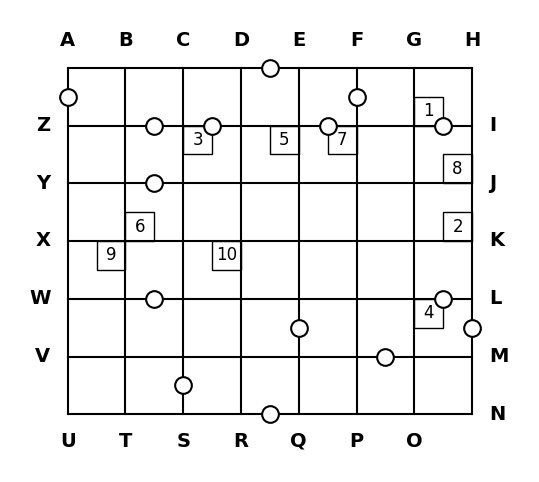

In [1]:
import matplotlib.pyplot as plt
import random
import string

def draw_grid_and_store_info(rows, cols, num_blocked_edges=20, num_buildings=10):
    fig, ax = plt.subplots(figsize=(cols, rows))
    point_info = {}

    # 初始化顶点信息
    for x in range(cols + 1):
        for y in range(rows + 1):
            point_info[(x, y)] = [
                1 if y < rows else 0,  # 上
                1 if y > 0 else 0,     # 下
                1 if x > 0 else 0,     # 左
                1 if x < cols else 0,  # 右
                [0, 0, 0, 0],          # 建筑信息[右上, 左上, 左下, 右下]
                ''                     # 字母标记（外围顶点）
            ]

    # 标记外围顶点（顺时针方向，从左上角开始）
    letters = list(string.ascii_uppercase)
    perimeter_points = []

    # 上边从左到右
    perimeter_points += [(x, rows) for x in range(cols + 1)]
    # 右边从上到下（不含第一个点）
    perimeter_points += [(cols, y) for y in range(rows - 1, -1, -1)]
    # 下边从右到左（不含第一个点）
    perimeter_points += [(x, 0) for x in range(cols - 1, -1, -1)]
    # 左边从下到上（不含第一个和最后一个点）
    perimeter_points += [(0, y) for y in range(1, rows)]

    # 字母标记稍微悬浮在外侧
    offset = 0.3
    for idx, (x, y) in enumerate(perimeter_points):
        letter = letters[idx % len(letters)]
        point_info[(x, y)][5] = letter

        # 根据位置确定字母偏移方向
        if y == rows:  # 上边
            ax.text(x, y + offset, letter, fontsize=14, color='black', ha='center', va='bottom', fontweight='bold')
        elif x == cols:  # 右边
            ax.text(x + offset, y, letter, fontsize=14, color='black', ha='left', va='center', fontweight='bold')
        elif y == 0:  # 下边
            ax.text(x, y - offset, letter, fontsize=14, color='black', ha='center', va='top', fontweight='bold')
        elif x == 0:  # 左边
            ax.text(x - offset, y, letter, fontsize=14, color='black', ha='right', va='center', fontweight='bold')

    # 所有可能的边
    edges = []
    for x in range(cols + 1):
        for y in range(rows + 1):
            if x < cols:
                edges.append(((x, y), (x + 1, y)))
            if y < rows:
                edges.append(((x, y), (x, y + 1)))

    # 随机阻塞边
    blocked_edges = random.sample(edges, min(num_blocked_edges, len(edges)))

    # 更新阻塞边信息
    for (start, end) in blocked_edges:
        x1, y1 = start
        x2, y2 = end
        if x1 == x2:  # 垂直边
            if y2 > y1:
                point_info[start][0] = 0
                point_info[end][1] = 0
            else:
                point_info[start][1] = 0
                point_info[end][0] = 0
        else:  # 水平边
            if x2 > x1:
                point_info[start][3] = 0
                point_info[end][2] = 0
            else:
                point_info[start][2] = 0
                point_info[end][3] = 0

    # 随机选择格子放置建筑
    all_cells = [(x, y) for x in range(cols) for y in range(rows)]
    building_cells = random.sample(all_cells, min(num_buildings, len(all_cells)))

    building_number = 1
    for (x, y) in building_cells:
        position = random.randint(1, 4)  # 1右上, 2左上, 3左下, 4右下
        half_size = 0.5
        if position == 1:  # 右上
            rect_x, rect_y = x + half_size, y + half_size
            point_info[(x + 1, y + 1)][4][2] = building_number
        elif position == 2:  # 左上
            rect_x, rect_y = x, y + half_size
            point_info[(x, y + 1)][4][3] = building_number
        elif position == 3:  # 左下
            rect_x, rect_y = x, y
            point_info[(x, y)][4][0] = building_number
        else:  # 右下
            rect_x, rect_y = x + half_size, y
            point_info[(x + 1, y)][4][1] = building_number

        building_rect = plt.Rectangle((rect_x, rect_y), half_size, half_size,
                                      facecolor='white', edgecolor='black')
        ax.add_patch(building_rect)

        ax.text(rect_x + half_size / 2, rect_y + half_size / 2, str(building_number),
                fontsize=12, ha='center', va='center')

        building_number += 1

    # 绘制网格线
    for x in range(cols + 1):
        ax.plot([x, x], [0, rows], color='black')
    for y in range(rows + 1):
        ax.plot([0, cols], [y, y], color='black')

    # 绘制阻塞边圆圈
    for (start, end) in blocked_edges:
        mid_x = (start[0] + end[0]) / 2
        mid_y = (start[1] + end[1]) / 2
        ax.plot(mid_x, mid_y, 'o', markersize=12, markerfacecolor='white',
                markeredgecolor='black', markeredgewidth=1.5)

    ax.set_xlim(-1, cols + 1)
    ax.set_ylim(-1, rows + 1)
    ax.set_aspect('equal')
    ax.axis('off')
    plt.show()

    return point_info

# 调用函数并输出结果
rows, cols = 6, 7
grid_info = draw_grid_and_store_info(rows, cols, num_blocked_edges=15, num_buildings=10)


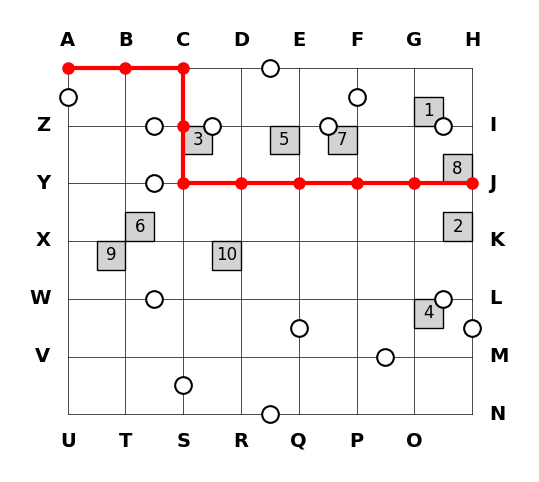

路径经过的建筑数量： 1
路径经过的建筑编号： {8}


In [10]:
import matplotlib.pyplot as plt
from collections import deque

# 辅助函数：根据字母找到对应的顶点坐标
def find_point_by_letter(grid_info, letter):
    for coord, info in grid_info.items():
        if info[5] == letter:
            return coord
    return None

# BFS算法寻找最短路径
def bfs_shortest_path(grid_info, start, end):
    queue = deque()
    queue.append(start)
    visited = {start: None}

    directions = [(0,1), (0,-1), (-1,0), (1,0)] # 上下左右

    while queue:
        current = queue.popleft()

        if current == end:
            break

        x, y = current
        edges = grid_info[current][:4]  # 上下左右的边状态
        for idx, (dx, dy) in enumerate(directions):
            if edges[idx] == 1:  # 边存在
                next_point = (x + dx, y + dy)
                if next_point in grid_info and next_point not in visited:
                    visited[next_point] = current
                    queue.append(next_point)

    # 回溯路径
    path = []
    if end in visited:
        current = end
        while current:
            path.append(current)
            current = visited[current]
        path.reverse()
    return path

# 绘制路径函数
def draw_path(grid_info, path, rows, cols):
    fig, ax = plt.subplots(figsize=(cols, rows))

    # 重绘网格线
    for x in range(cols + 1):
        ax.plot([x, x], [0, rows], color='black', linewidth=0.5)
    for y in range(rows + 1):
        ax.plot([0, cols], [y, y], color='black', linewidth=0.5)

    # 重绘阻塞边圆圈（关键修正位置）
    for (x, y), info in grid_info.items():
        edges = info[:4] # 上下左右
        directions = [(0,1), (0,-1), (-1,0), (1,0)]
        for idx, status in enumerate(edges):
            if status == 0:
                dx, dy = directions[idx]
                neighbor = (x + dx, y + dy)
                if neighbor in grid_info and (x, y) < neighbor: # 避免重复绘制
                    mid_x = (x + neighbor[0]) / 2
                    mid_y = (y + neighbor[1]) / 2
                    ax.plot(mid_x, mid_y, 'o', markersize=12, markerfacecolor='white',
                            markeredgecolor='black', markeredgewidth=1.5)

    # 重绘建筑
    for coord, info in grid_info.items():
        buildings = info[4]
        x, y = coord
        half_size = 0.5
        offsets = [(0,0), (-half_size,0), (-half_size,-half_size), (0,-half_size)]
        for idx, b_num in enumerate(buildings):
            if b_num != 0:
                rect_x, rect_y = x + offsets[idx][0], y + offsets[idx][1]
                building_rect = plt.Rectangle((rect_x, rect_y), half_size, half_size,
                                              facecolor='lightgray', edgecolor='black')
                ax.add_patch(building_rect)
                ax.text(rect_x + half_size / 2, rect_y + half_size / 2, str(b_num),
                        fontsize=12, ha='center', va='center')

    # 重绘外围字母
    offset = 0.3
    for coord, info in grid_info.items():
        letter = info[5]
        if letter:
            x, y = coord
            if y == rows:
                ax.text(x, y + offset, letter, fontsize=14, color='black', ha='center', va='bottom', fontweight='bold')
            elif x == cols:
                ax.text(x + offset, y, letter, fontsize=14, color='black', ha='left', va='center', fontweight='bold')
            elif y == 0:
                ax.text(x, y - offset, letter, fontsize=14, color='black', ha='center', va='top', fontweight='bold')
            elif x == 0:
                ax.text(x - offset, y, letter, fontsize=14, color='black', ha='right', va='center', fontweight='bold')

    # 绘制路径
    if path:
        path_x, path_y = zip(*path)
        ax.plot(path_x, path_y, color='red', linewidth=3, marker='o', markersize=8)
    else:
        print("未找到路径！")

    ax.set_xlim(-1, cols + 1)
    ax.set_ylim(-1, rows + 1)
    ax.set_aspect('equal')
    ax.axis('off')
    plt.show()

def count_passed_buildings(grid_info, path):
    passed_buildings = set()

    for i in range(1, len(path)):
        prev = path[i - 1]
        curr = path[i]
        px, py = prev
        cx, cy = curr

        # 获取当前位置的建筑信息
        building_info = grid_info[curr][4]

        # 判断移动方向
        dx = cx - px
        dy = cy - py

        if dx == 1:  # 从左向右移动
            # 检查当前点左侧的建筑（左上、左下）
            if building_info[1] != 0:
                passed_buildings.add(building_info[1])
            if building_info[2] != 0:
                passed_buildings.add(building_info[2])

        elif dx == -1:  # 从右向左移动
            # 检查当前点右侧的建筑（右上、右下）
            if building_info[0] != 0:
                passed_buildings.add(building_info[0])
            if building_info[3] != 0:
                passed_buildings.add(building_info[3])

        elif dy == 1:  # 从下向上移动
            # 检查当前点下侧的建筑（左下、右下）
            if building_info[2] != 0:
                passed_buildings.add(building_info[2])
            if building_info[3] != 0:
                passed_buildings.add(building_info[3])

        elif dy == -1:  # 从上向下移动
            # 检查当前点上侧的建筑（左上、右上）
            if building_info[1] != 0:
                passed_buildings.add(building_info[1])
            if building_info[0] != 0:
                passed_buildings.add(building_info[0])

    return passed_buildings

# 用户指定两个字母
letter_start = 'A'  # 起点字母
letter_end = 'J'    # 终点字母

# 根据字母找到对应的顶点坐标
start_point = find_point_by_letter(grid_info, letter_start)
end_point = find_point_by_letter(grid_info, letter_end)

if start_point and end_point:
    path = bfs_shortest_path(grid_info, start_point, end_point)
    draw_path(grid_info, path, rows, cols)
    buildings_passed = count_passed_buildings(grid_info, path)
    print("路径经过的建筑数量：", len(buildings_passed))
    print("路径经过的建筑编号：", buildings_passed)
else:
    print("未找到指定字母对应的顶点，请检查字母输入是否正确！")


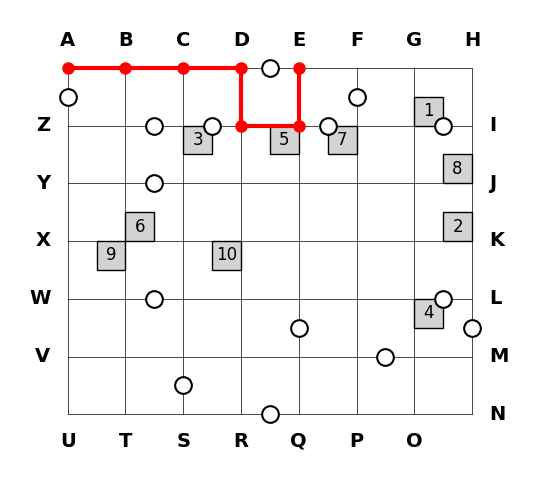

路径经过的建筑数量为：1
经过的建筑编号为：[3]


In [6]:
def count_buildings_on_path(grid_info, path):
    buildings_passed = set()

    for i in range(len(path)-1):
        x1, y1 = path[i]
        x2, y2 = path[i+1]

        # 确定移动方向
        dx, dy = x2 - x1, y2 - y1

        if dx == 1:  # 向右移动，经过右侧边
            cells_to_check = [(x1, y1), (x1, y1-1)]
            building_indices = [0, 3]  # 右上(0), 右下(3)
        elif dx == -1:  # 向左移动，经过左侧边
            cells_to_check = [(x2, y2), (x2, y2-1)]
            building_indices = [1, 2]  # 左上(1), 左下(2)
        elif dy == 1:  # 向上移动，经过上侧边
            cells_to_check = [(x1, y1), (x1-1, y1)]
            building_indices = [0, 1]  # 右上(0), 左上(1)
        elif dy == -1:  # 向下移动，经过下侧边
            cells_to_check = [(x2, y2), (x2-1, y2)]
            building_indices = [2, 3]  # 左下(2), 右下(3)
        else:
            continue  # 不应该发生

        for cell, idx in zip(cells_to_check, building_indices):
            if cell in grid_info:
                building_number = grid_info[cell][4][idx]
                if building_number != 0:
                    buildings_passed.add(building_number)

    return len(buildings_passed), buildings_passed

# 在原先的绘制路径代码后面增加统计建筑的功能：
if start_point and end_point:
    path = bfs_shortest_path(grid_info, start_point, end_point)
    if path:
        draw_path(grid_info, path, rows, cols)
        num_buildings, buildings_set = count_buildings_on_path(grid_info, path)
        print(f"路径经过的建筑数量为：{num_buildings}")
        print(f"经过的建筑编号为：{sorted(buildings_set)}")
    else:
        print("未找到路径！")
else:
    print("未找到指定字母对应的顶点，请检查字母输入是否正确！")


In [7]:
for y in range(rows, -1, -1):
    for x in range(cols + 1):
        info = grid_info[(x, y)]
        print(f"顶点({x},{y}): 上:{info[0]} 下:{info[1]} 左:{info[2]} 右:{info[3]} 建筑[右上,左上,左下,右下]:{info[4]}")
    print("-" * 80)

顶点(0,6): 上:0 下:0 左:0 右:1 建筑[右上,左上,左下,右下]:[0, 0, 0, 0]
顶点(1,6): 上:0 下:1 左:1 右:1 建筑[右上,左上,左下,右下]:[0, 0, 0, 0]
顶点(2,6): 上:0 下:1 左:1 右:1 建筑[右上,左上,左下,右下]:[0, 0, 0, 0]
顶点(3,6): 上:0 下:1 左:1 右:0 建筑[右上,左上,左下,右下]:[0, 0, 0, 0]
顶点(4,6): 上:0 下:1 左:0 右:1 建筑[右上,左上,左下,右下]:[0, 0, 0, 0]
顶点(5,6): 上:0 下:0 左:1 右:1 建筑[右上,左上,左下,右下]:[0, 0, 0, 0]
顶点(6,6): 上:0 下:1 左:1 右:1 建筑[右上,左上,左下,右下]:[0, 0, 0, 0]
顶点(7,6): 上:0 下:1 左:1 右:0 建筑[右上,左上,左下,右下]:[0, 0, 0, 0]
--------------------------------------------------------------------------------
顶点(0,5): 上:0 下:1 左:0 右:1 建筑[右上,左上,左下,右下]:[0, 0, 0, 0]
顶点(1,5): 上:1 下:1 左:1 右:0 建筑[右上,左上,左下,右下]:[0, 0, 0, 0]
顶点(2,5): 上:1 下:1 左:0 右:0 建筑[右上,左上,左下,右下]:[0, 0, 0, 3]
顶点(3,5): 上:1 下:1 左:0 右:1 建筑[右上,左上,左下,右下]:[0, 0, 0, 0]
顶点(4,5): 上:1 下:1 左:1 右:0 建筑[右上,左上,左下,右下]:[0, 0, 5, 0]
顶点(5,5): 上:0 下:1 左:0 右:1 建筑[右上,左上,左下,右下]:[0, 0, 7, 0]
顶点(6,5): 上:1 下:1 左:1 右:0 建筑[右上,左上,左下,右下]:[1, 0, 0, 0]
顶点(7,5): 上:1 下:1 左:0 右:0 建筑[右上,左上,左下,右下]:[0, 0, 0, 0]
-------------------------------------------------------